In [278]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
import re

sns.set_theme(style="whitegrid")

In [279]:
csv_path = Path("../mpact_rates.csv")

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"✅ Loaded {len(df):,} rows from '{csv_path}'")
    display(df.head())
else:
    print(f"⚠️ File not found at '{csv_path}'. Please check the path.")

⚠️ File not found at '..\mpact_rates.csv'. Please check the path.


In [280]:
df['pulled_at'] = pd.to_datetime(df['pulled_at'])

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   pulled_at          600 non-null    datetime64[ns, UTC]
 1   endpoint_type      600 non-null    object             
 2   origin_zip3        600 non-null    int64              
 3   destination_zip3   600 non-null    int64              
 4   trailer_type       600 non-null    object             
 5   carrier_type       600 non-null    object             
 6   include_fuel       600 non-null    bool               
 7   include_quartiles  600 non-null    bool               
 8   average            600 non-null    float64            
 9   minimum            600 non-null    float64            
 10  maximum            600 non-null    float64            
 11  quartile1          600 non-null    float64            
 12  quartile2          600 non-null    float64        

pulled_at            0
endpoint_type        0
origin_zip3          0
destination_zip3     0
trailer_type         0
carrier_type         0
include_fuel         0
include_quartiles    0
average              0
minimum              0
maximum              0
quartile1            0
quartile2            0
quartile3            0
orders               0
contributors         0
days_window          0
dtype: int64

In [281]:
df_clean = df.dropna(subset=["average", "minimum", "maximum"])
print(f"Remaining rows after filtering: {len(df_clean):,}")

Remaining rows after filtering: 600


In [282]:
lane_counts = df_clean.groupby(['origin_zip3', 'destination_zip3']).size().reset_index(name='count')
top_lanes = lane_counts.sort_values(by='count', ascending=False).head(20)
top_lanes

,origin_zip3,destination_zip3,count
0,21,100,6
1,100,21,6
2,100,191,6
3,100,212,6
4,100,303,6
5,100,331,6
6,100,606,6
7,100,750,6
8,100,770,6
9,100,900,6


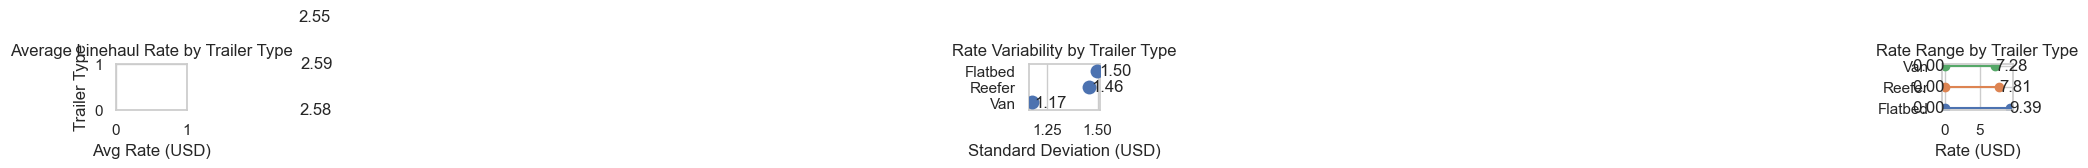

In [283]:
summary_stats = (
    df_clean.groupby('trailer_type')['average']
    .agg(['count', 'mean', 'min', 'max', 'std'])
    .reset_index()
    .rename(columns={
        'count': 'Request Count',
        'mean': 'Avg Rate',
        'min': 'Min Rate',
        'max': 'Max Rate',
        'std': 'Rate Std Dev'
    })
)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, row in summary_stats.iterrows():
    axes[0].text(row['Avg Rate'] + 0.01, i, f"{row['Avg Rate']:.2f}", va='center')
axes[0].set_title('Average Linehaul Rate by Trailer Type')
axes[0].set_xlabel('Avg Rate (USD)')
axes[0].set_ylabel('Trailer Type')

sns.stripplot(data=summary_stats, x='Rate Std Dev', y='trailer_type', size=10, ax=axes[1])
for i, row in summary_stats.iterrows():
    axes[1].text(row['Rate Std Dev'] + 0.01, i, f"{row['Rate Std Dev']:.2f}", va='center')
axes[1].set_title('Rate Variability by Trailer Type')
axes[1].set_xlabel('Standard Deviation (USD)')
axes[1].set_ylabel('')

for i, row in summary_stats.iterrows():
    axes[2].plot([row['Min Rate'], row['Max Rate']], [row['trailer_type']] * 2, marker='o')
    axes[2].text(row['Min Rate'], i, f"{row['Min Rate']:.2f}", va='center', ha='right')
    axes[2].text(row['Max Rate'], i, f"{row['Max Rate']:.2f}", va='center', ha='left')
axes[2].set_title('Rate Range by Trailer Type')
axes[2].set_xlabel('Rate (USD)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()


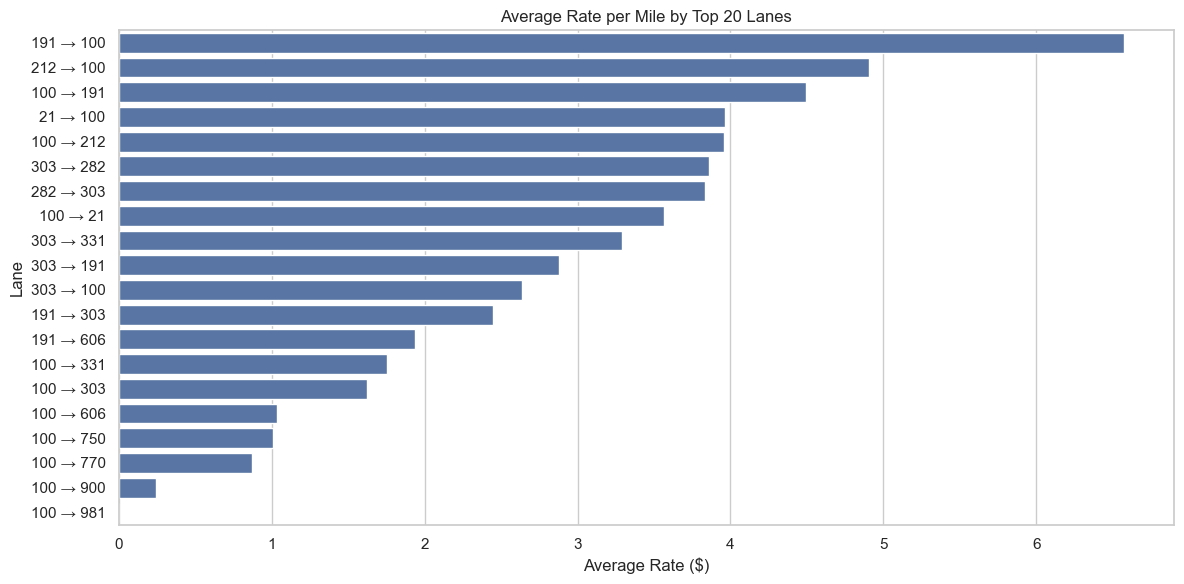

In [284]:
top_lane_rates = df_clean[
    df_clean[['origin_zip3', 'destination_zip3']].apply(tuple, axis=1).isin(
        top_lanes[['origin_zip3', 'destination_zip3']].apply(tuple, axis=1)
    )
]

lane_avg = top_lane_rates.groupby(['origin_zip3', 'destination_zip3'])['average'].mean().reset_index()

lane_avg['lane'] = lane_avg['origin_zip3'].astype(str) + ' → ' + lane_avg['destination_zip3'].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=lane_avg.sort_values(by='average', ascending=False), x='average', y='lane')
plt.title('Average Rate per Mile by Top 20 Lanes')
plt.xlabel('Average Rate ($)')
plt.ylabel('Lane')
plt.tight_layout()
plt.show()


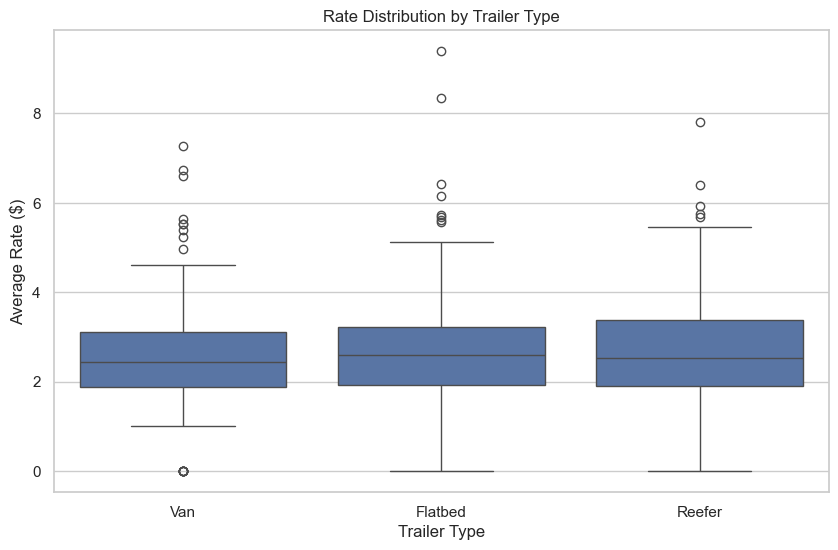

In [285]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='trailer_type', y='average')
plt.title('Rate Distribution by Trailer Type')
plt.xlabel('Trailer Type')
plt.ylabel('Average Rate ($)')
plt.show()

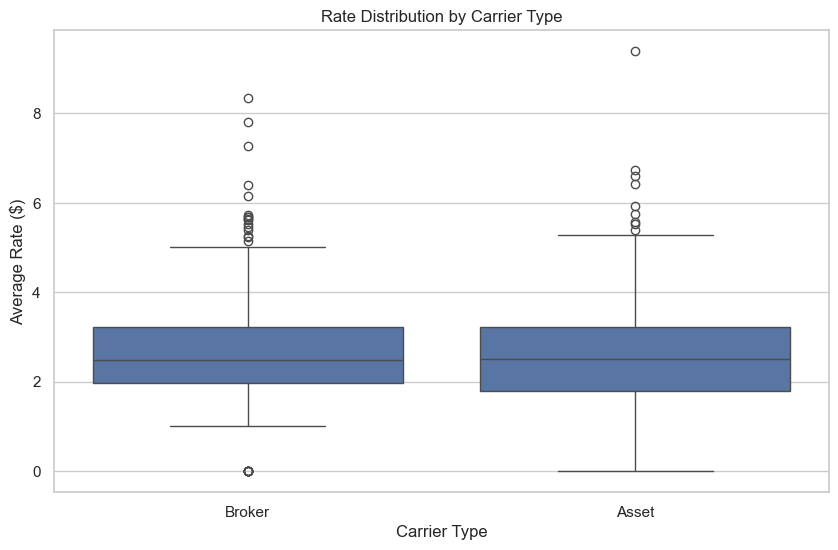

In [286]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='carrier_type', y='average')
plt.title('Rate Distribution by Carrier Type')
plt.xlabel('Carrier Type')
plt.ylabel('Average Rate ($)')
plt.show()

In [287]:
summary = df_clean.groupby(['origin_zip3', 'destination_zip3', 'trailer_type', 'carrier_type']).agg(
    avg_rate=('average', 'mean'),
    min_rate=('minimum', 'mean'),
    max_rate=('maximum', 'mean'),
    count=('average', 'count')
).reset_index()

summary.to_csv("freight_summary_powerbi.csv", index=False)
summary.head()

,origin_zip3,destination_zip3,trailer_type,carrier_type,avg_rate,min_rate,max_rate,count
0,21,100,Flatbed,Asset,5.58,3.40,9.90,1
1,21,100,Flatbed,Broker,4.93,2.74,7.07,1
2,21,100,Reefer,Asset,0.00,0.00,0.00,1
3,21,100,Reefer,Broker,4.57,3.18,5.66,1
4,21,100,Van,Asset,4.36,1.38,6.36,1


MSE: 0.7547
MAE: $0.53
RMSE: 0.8687
R² Score: 0.5628


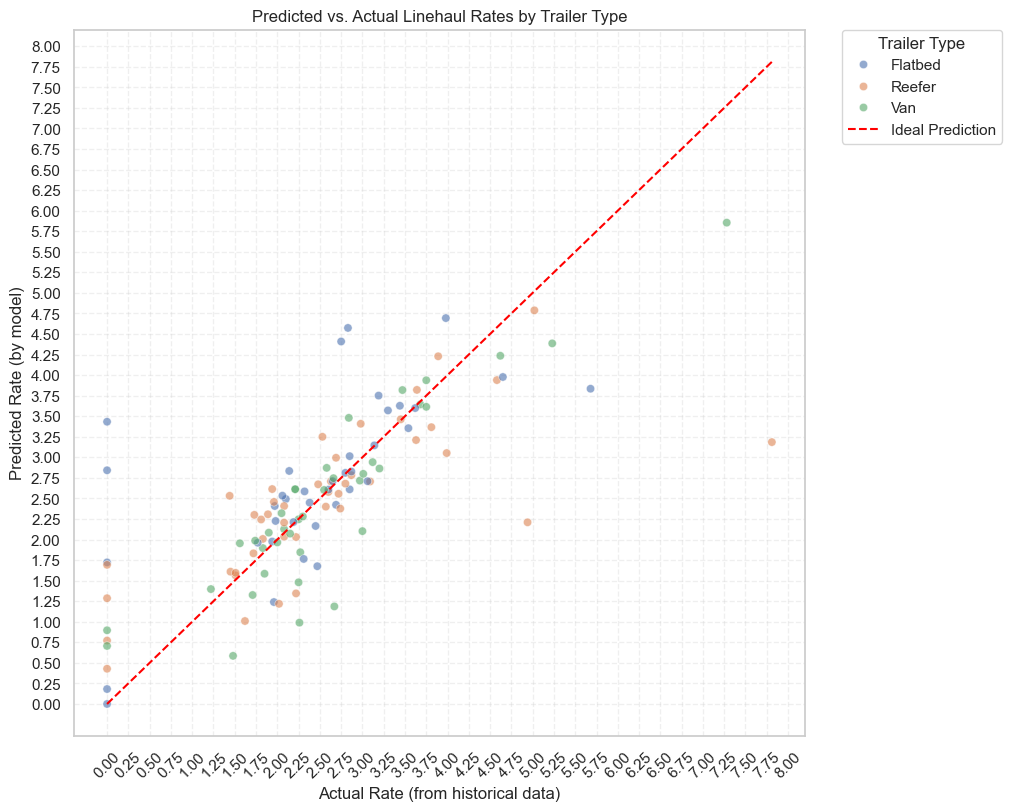

In [288]:
features = ['origin_zip3', 'destination_zip3', 'trailer_type', 'carrier_type', 'lane']
target = 'average'

df_model = df_clean.dropna(subset=[target])

df_model['lane'] = df_model['origin_zip3'].astype(str) + ' → ' + df_model['destination_zip3'].astype(str)

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_encoded = ohe.fit_transform(df_model[features])

y = df_model[target].values
trailer_types = df_model['trailer_type'].values  # Needed for plotting

X_train, X_test, y_train, y_test, trailer_train, trailer_test = train_test_split(
    X_encoded, y, trailer_types, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"MAE: ${mae:.2f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

results_df = pd.DataFrame({
    'Actual Rate': y_test,
    'Predicted Rate': y_pred,
    'Trailer Type': trailer_test
})

plt.figure(figsize=(10, 8), constrained_layout=True)
sns.scatterplot(data=results_df, x='Actual Rate', y='Predicted Rate', hue='Trailer Type', alpha=0.6)

min_rate = 0
max_rate = max(results_df['Actual Rate'].max(), results_df['Predicted Rate'].max())
plt.plot([min_rate, max_rate], [min_rate, max_rate], color='red', linestyle='--', label='Ideal Prediction')

tick_range = np.arange(min_rate, max_rate + 0.25, 0.25)
plt.xticks(tick_range, rotation=45)
plt.yticks(tick_range)

plt.xlabel("Actual Rate (from historical data)")
plt.ylabel("Predicted Rate (by model)")
plt.title("Predicted vs. Actual Linehaul Rates by Trailer Type")

plt.legend(title='Trailer Type', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.grid(True, linestyle='--', alpha=0.3)
plt.show()
